In [22]:
#===============================
# ANALYSE : Mouad AOUS | Ingénieur Qualité de l'Air
# Dataset : Climat Cha,ge - Earth Surface Temprature
#================================

In [63]:
from zipfile import ZipFile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.colors import Normalize
from matplotlib.cm import RdYlBu_r
import warnings
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
warnings.filterwarnings("ignore")
import matplotlib.cm as cm


In [6]:
if os.path.exists('../Kaggle/input/'):
    BASE_PATH = '../kaggle/input/'
    print("Environnment Kaggle détécté")
else:
    BASE_PATH = '../data'
    print("Envirennment local détecté")
print(f"Chemin: {BASE_PATH}")


Environnment Kaggle détécté
Chemin: ../kaggle/input/


In [7]:
with ZipFile(f'{BASE_PATH}archive.zip') as filezip:
    filezip.extractall(f"{BASE_PATH}")
files = [f for f in os.listdir(f"{BASE_PATH}") if f.endswith(".csv")]
print("=" * 50)
for file in files:
    print(f"Nom des fichier avec les données: #----- {file}")
print("=" * 50)

Nom des fichier avec les données: #----- GlobalLandTemperaturesByCountry.csv
Nom des fichier avec les données: #----- GlobalLandTemperaturesByMajorCity.csv
Nom des fichier avec les données: #----- GlobalLandTemperaturesByState.csv
Nom des fichier avec les données: #----- GlobalTemperatures.csv
Nom des fichier avec les données: #----- GlobalLandTemperaturesByCity.csv


In [8]:
# Data
df = pd.read_csv(f'{BASE_PATH}/GlobalTemperatures.csv')
print(f"Dimensions: {df.shape}")
print(f" -> {df.shape[0]} lignes qui signifie Nombre de mois enregistrées  est éagle à {df.shape[0]/12} ans")
print(f" -> {df.shape[1]} colonnes")
print(f"\n Colonnes:")
for col in df.columns:
    print(f"  -> {col}")
print(f"Aperçu:")
print("Types de données")
print('=' * 50)
print(df.dtypes)

Dimensions: (3192, 9)
 -> 3192 lignes qui signifie Nombre de mois enregistrées  est éagle à 266.0 ans
 -> 9 colonnes

 Colonnes:
  -> dt
  -> LandAverageTemperature
  -> LandAverageTemperatureUncertainty
  -> LandMaxTemperature
  -> LandMaxTemperatureUncertainty
  -> LandMinTemperature
  -> LandMinTemperatureUncertainty
  -> LandAndOceanAverageTemperature
  -> LandAndOceanAverageTemperatureUncertainty
Aperçu:
Types de données
dt                                            object
LandAverageTemperature                       float64
LandAverageTemperatureUncertainty            float64
LandMaxTemperature                           float64
LandMaxTemperatureUncertainty                float64
LandMinTemperature                           float64
LandMinTemperatureUncertainty                float64
LandAndOceanAverageTemperature               float64
LandAndOceanAverageTemperatureUncertainty    float64
dtype: object


In [9]:
print("# Valeur manquantes")
print("=" * 50)
missing= df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
for col in df.columns:
    print(f" {col:45s} ->   "
          f"{missing[col]:4d}    manquants"
          f"\t   {missing_pct[col]}%")

# Valeur manquantes
 dt                                            ->      0    manquants	   0.0%
 LandAverageTemperature                        ->     12    manquants	   0.38%
 LandAverageTemperatureUncertainty             ->     12    manquants	   0.38%
 LandMaxTemperature                            ->   1200    manquants	   37.59%
 LandMaxTemperatureUncertainty                 ->   1200    manquants	   37.59%
 LandMinTemperature                            ->   1200    manquants	   37.59%
 LandMinTemperatureUncertainty                 ->   1200    manquants	   37.59%
 LandAndOceanAverageTemperature                ->   1200    manquants	   37.59%
 LandAndOceanAverageTemperatureUncertainty     ->   1200    manquants	   37.59%


In [10]:
# Traitement des données 
df_clean = df.copy()
df_clean['dt'] = pd.to_datetime(df_clean['dt'])
print(f"Conversion datetimes : {df_clean['dt'].dtype}")
print("\n" + "=" * 50)
print(f"Première date: {df_clean['dt'].min()}")
print(f"Dernier date: {df_clean['dt'].max()}")
df_clean['Year'] = df_clean['dt'].dt.year
df_clean['month'] = df_clean['dt'].dt.month
print(f"\n Nouvelles colonnes:")
print(f" year  :  de {df_clean['Year'].min()}" f" à {df_clean['Year'].max()}")
print(f" month : de {df_clean['month'].min()}" f" à {df_clean['month'].max()}")
# Supprimer les 12 lignes sans température
avant = len(df_clean)
df_clean = df_clean.dropna(subset=['LandAverageTemperature'])
après = len(df_clean)
print(f"\n Suppression des lignes sans température:")
print(f"Avant : {avant} lignes")
print(f"Après: {après} lignes ")

Conversion datetimes : datetime64[ns]

Première date: 1750-01-01 00:00:00
Dernier date: 2015-12-01 00:00:00

 Nouvelles colonnes:
 year  :  de 1750 à 2015
 month : de 1 à 12

 Suppression des lignes sans température:
Avant : 3192 lignes
Après: 3180 lignes 


# We are trying to responds this question:
 - what is the mean global temperature
 - What is the min temperature ever sample
 - What is the max ""
 

In [11]:
temp = df_clean['LandAverageTemperature']
print("=" * 50)
print("STATISTIQUES - Température Mondiale")
print("=" * 50)
print(f" Moyenne mondiale : {temp.mean():.2f} °C")
print(f" Plus froide : {temp.min():.2f} °C")
print(f" Plus chaude : {temp.max():.2f} °C")
print(f" Ecarte-type : {temp.std():.2f} °C")
idx_min = temp.idxmin()
idx_max = temp.idxmax()
print(f"\n Date la plus froide : "
        f"{df_clean.loc[idx_min,'dt'].strftime('%B %Y')}"
        f" -> {temp.min():.2f} °C")
print(f" Date la plus chaude : "
      f"{df_clean.loc[idx_max,'dt'].strftime('%B %Y')}"
      f" -> {temp.max():.2f} °C")
print(f" Répartition par siècle :")
df_clean['siecle'] = (df_clean['Year'] // 100 + 1)
for s, group in df_clean.groupby('siecle'):
    print(f" {s}e siècle :"
          f"{len(group)} mesures "
          f"({group['Year'].min()} - {group['Year'].max()})")

STATISTIQUES - Température Mondiale
 Moyenne mondiale : 8.37 °C
 Plus froide : -2.08 °C
 Plus chaude : 19.02 °C
 Ecarte-type : 4.38 °C

 Date la plus froide : January 1768 -> -2.08 °C
 Date la plus chaude : July 1761 -> 19.02 °C
 Répartition par siècle :
 18e siècle :588 mesures (1750 - 1799)
 19e siècle :1200 mesures (1800 - 1899)
 20e siècle :1200 mesures (1900 - 1999)
 21e siècle :192 mesures (2000 - 2015)


In [12]:
# -- Moyenne annuelle ---------------
#
df_annuel = df_clean.groupby('Year').agg(
    temp_moyenne = ('LandAverageTemperature','mean'),
    temp_max = ('LandAverageTemperature','max'),
    temp_min = ('LandAverageTemperature','min')
).reset_index()
print("Données annuelles créées")
print(f"{len(df_annuel)} années de données")
print(f"\nAperçu")
print("\n" + 20 * '=' + "Head Data" + 20 *'=')
print(df_annuel.head(5).to_string())
print("\n" + 20 * '=' + "Tail Data" + 20 *'=')
print(df_annuel.tail(5).to_string())

Données annuelles créées
266 années de données

Aperçu

====================Head Data====================
   Year  temp_moyenne  temp_max  temp_min
0  1750      8.719364    15.868     2.772
1  1751      7.976143    14.405     0.963
2  1752      5.779833     8.265     0.348
3  1753      8.388083    15.092     0.559
4  1754      8.469333    14.681    -1.249

====================Tail Data====================
     Year  temp_moyenne  temp_max  temp_min
261  2011      9.516000    15.482     3.282
262  2012      9.507333    15.076     3.157
263  2013      9.606500    15.003     3.685
264  2014      9.570667    14.875     3.500
265  2015      9.831000    15.051     3.881


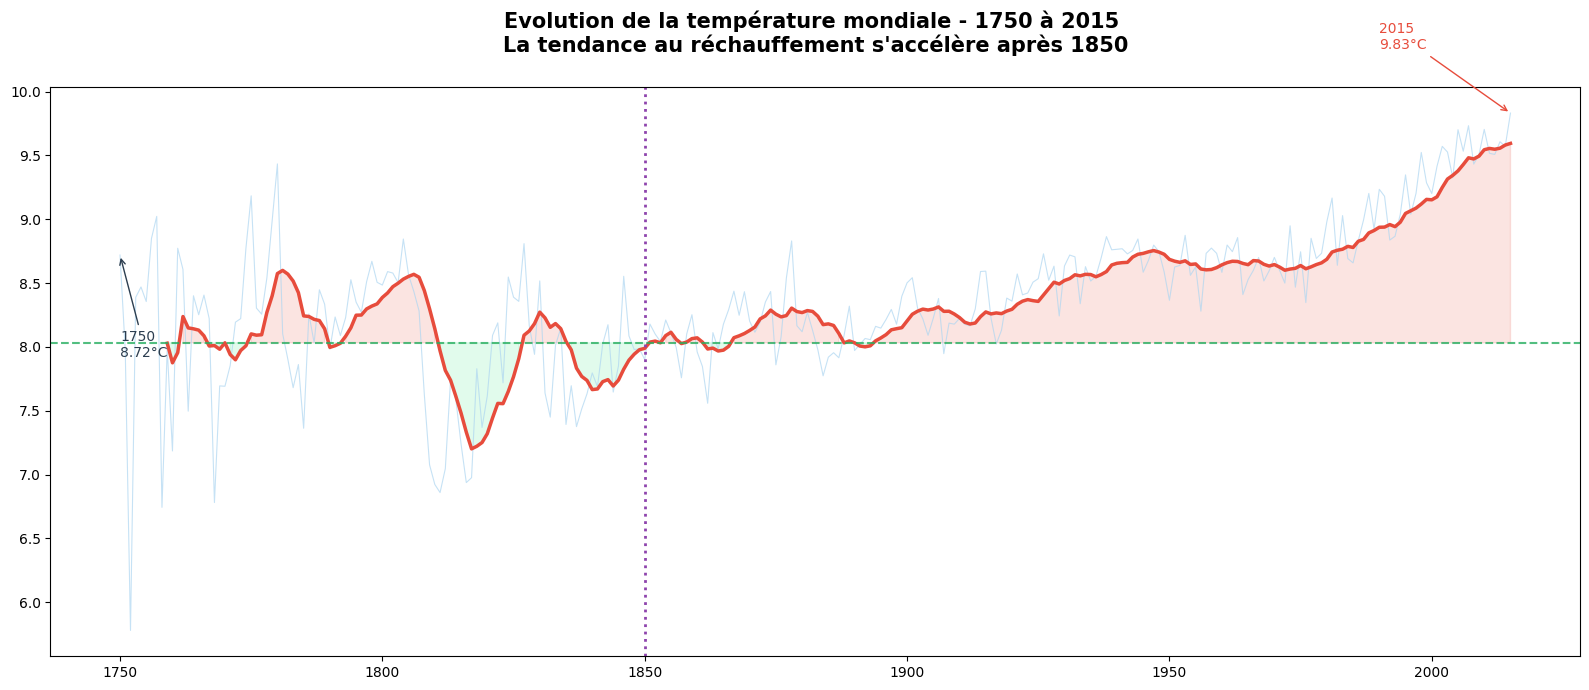

Température référence pré-industrielle : 8.03°C
Température 2015                    : 9.83°C
Réchauffement total                 : +1.80°C


In [13]:
# --- Moyenne mobile sur 10 ans ------
# rolling(10) = fênetre glissante de 10 ans
df_annuel['tendance_10ans'] = (df_annuel['temp_moyenne'].rolling(10).mean())
fig, ax = plt.subplots(figsize=(16,7))
ax.plot(
    df_annuel['Year'],df_annuel['temp_moyenne'],color='#AED6F1',
    linewidth=0.8,alpha=0.7,label='Températur annuelle'
)
ax.plot(df_annuel['Year'],df_annuel['tendance_10ans'],color='#E74C3C',linewidth=2.5,label='Tendance (moyenne mobile 10 ans)')
# --- Ligne de référence pré-inductrielle
#on calcule la moyenne de 1750 à 1850
#C'est la période Avant la révolution industrielle
#Utilisée comme référence par le GIEC
ref = df_annuel[df_annuel['Year'] <= 1850]['temp_moyenne'].mean()
ax.axhline(y=ref,color='#27AE60',linestyle='--',linewidth=1.5,
           alpha=0.8,label=f'Référence pré-industrielle:{ref:.2f}°C')
# -- Zone de réchauffement ---------
ax.fill_between(df_annuel['Year'],df_annuel['tendance_10ans'],ref,
                where = df_annuel['tendance_10ans'] >= ref,alpha=0.15,color='#E74C3C',label='Zone de réchauffement')
ax.fill_between(df_annuel['Year'],df_annuel['tendance_10ans'],ref,
                where = df_annuel['tendance_10ans'] < ref,alpha=0.15,color="#3CE783",label='Zone de baisse')
# --- Ligne révolution industrielle ---------------
ax.axvline(
    x=1850,color='#8E44AD',linestyle=':',linewidth=2,label='Révolution industrielle (1850)'
)
#--- Mise en forme ------
ax.set_title('Evolution de la température mondiale - 1750 à 2015 \n'
             'La tendance au réchauffement s\'accélère après 1850',
             fontsize=15,fontweight='bold',pad=25)
ax.annotate(
    f"1750\n{df_annuel.iloc[0]['temp_moyenne']:.2F}°C",
    xy=(1750,df_annuel.iloc[0]['temp_moyenne']),
    xytext=(1750,df_annuel.iloc[0]['temp_moyenne'] - 0.8),
    fontsize=10,color='#2C3E50',arrowprops=dict(arrowstyle='->',color='#2C3E50')
)
ax.annotate(f"2015\n{df_annuel.iloc[-1]['temp_moyenne']:.2f}°C",
            xy=(2015,df_annuel.iloc[-1]['temp_moyenne']),xytext=(1990,df_annuel.iloc[-1]['temp_moyenne']+0.5),fontsize=10,color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'))
plt.tight_layout()
plt.savefig('../outputs/01_revolution_temperature.png',dpi=150, bbox_inches='tight')
plt.show()
print(f"Température référence pré-industrielle : {ref:.2f}°C")
print(f"Température 2015                    :"
      f" {df_annuel.iloc[-1]['temp_moyenne']:.2f}°C")
print(f"Réchauffement total                 :"
      f" +{df_annuel.iloc[-1]['temp_moyenne'] - ref:.2f}°C")

Le rapport du GIEC 2021 dit:
"Limiter le réchaffement à 1.5°C pour éviter les effets les plus graves"
"Vptre analyse montre +1.80°C en 2015"
-> on a déjà dépassé le seuil de +1.5°C !
-> et ça continue d'augmenter après 2015
C'est exactement le chiffre que publient
les organismes scientifiques mondiaux
-> votre analyse est cohérente avec la science


In [ ]:
# ->  On travaille sur les anomalie thermique
# -> on affiche l'ecart par rapport à une référence
# -> la référence dans notre cas (1850-1900) = 8.03°C
# - exemple anomalie à 2015 = température à 2015 - temperature réf(1850-1900)

In [15]:
reference = df_annuel[(df_annuel['Year']>=1850)& (df_annuel['Year']<=1900)]['temp_moyenne'].mean()
# Anomalie = température année - référence
df_annuel['anomalie'] = (df_annuel['temp_moyenne'] - reference)
print(f"Référence (1850-1900): {reference:.2f}°C")
print(f"\n Anomalie 1850 : "
      f"{df_annuel[df_annuel['Year']==1850]['anomalie'].values[0]:+.2f}")
print(f"\n Anomalie 1950 : "
      f"{df_annuel[df_annuel['Year']==1950]['anomalie'].values[0]:+.2f}")
print(f"\n Anomalie 2015 : "
      f"{df_annuel[df_annuel['Year']==2015]['anomalie'].values[0]:+.2f}")

Référence (1850-1900): 8.14°C

 Anomalie 1850 : -0.24

 Anomalie 1950 : +0.23

 Anomalie 2015 : +1.69


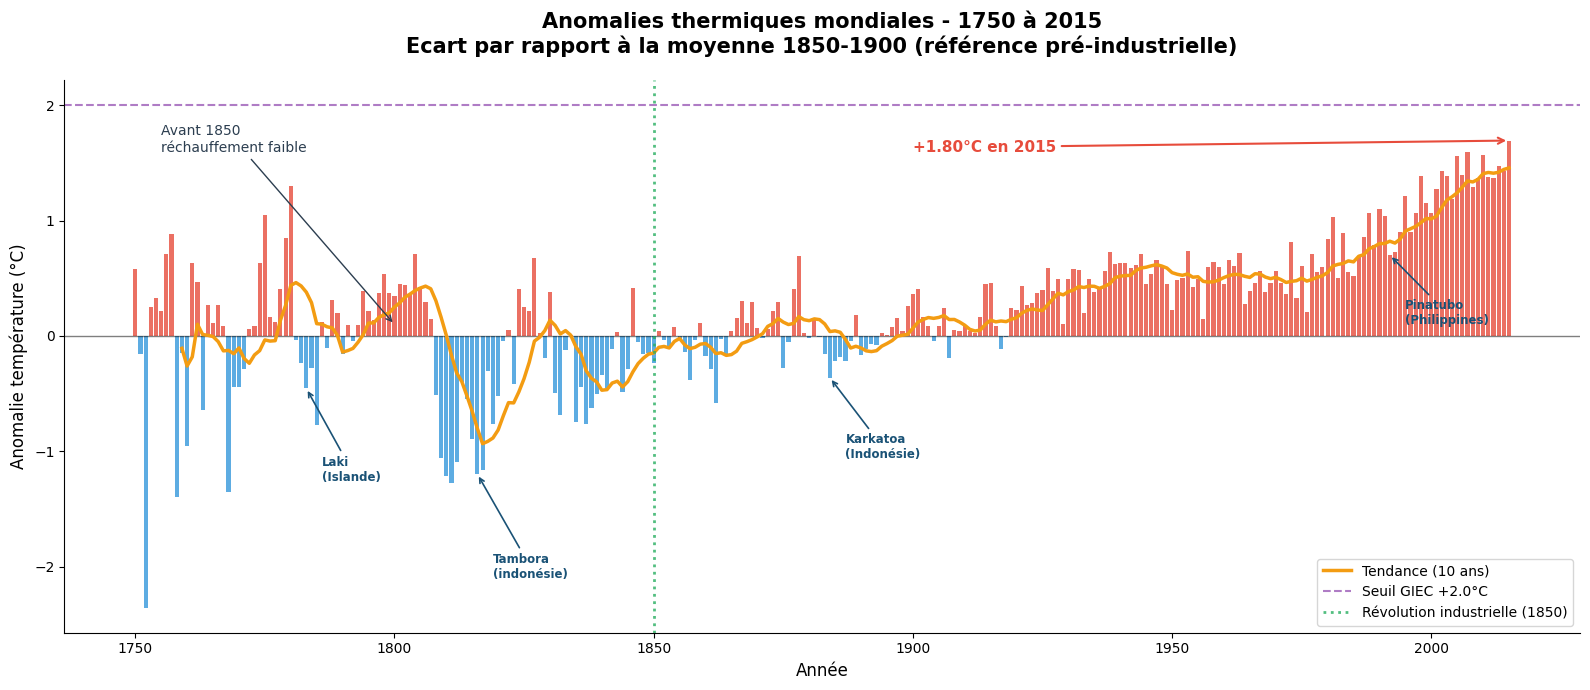

In [16]:
fig, ax = plt.subplots(figsize=(16,7))
couleurs = ['#E74C3C' 
            if v >= 0 else '#3498DB' for v in df_annuel['anomalie']]
ax.bar(
    df_annuel['Year'],
    df_annuel['anomalie'],
    color=couleurs,
    width=0.8,
    alpha=0.8
)
ax.axhline(y=0,color='black',
           linewidth=1,linestyle='-',alpha=0.5)
anomalie_lisse = df_annuel['anomalie'].rolling(10).mean()
ax.plot(df_annuel['Year'],
        anomalie_lisse,color='#F39C12',linewidth=2.5,label='Tendance (10 ans)')
ax.axhline(y=2.0,color='#8E44AD',linewidth=1.5,linestyle='--',
           alpha=0.7,label='Seuil GIEC +2.0°C')
# Révolution industrielle
ax.axvline(
    x=1850,color="#27AE60",linewidth=2,linestyle=':'
,
alpha=0.8,label='Révolution industrielle (1850)')
#Ajout des cause de roifroidissement et rechauffement naturel
eruptions=[
    (1783,'Laki\n(Islande)',0.8),
    (1816,'Tambora\n(indonésie)', 0.9),
    (1884,'Karkatoa\n(Indonésie)',0.7),
    (1992,'Pinatubo\n(Philippines)',0.6)
]
for annee, nom, offset_text in eruptions:
    val = df_annuel[df_annuel['Year']==annee]['anomalie'].values[0]
    ax.annotate(
        nom,xy=(annee,val),
        xytext=(annee+3,val - offset_text),fontsize=8.5,color='#1A5276',
        fontweight='bold',arrowprops=dict(arrowstyle='->',color='#1A5276',lw=1.2)
    )
ax.annotate('+1.80°C en 2015',xy=(2015, df_annuel[df_annuel['Year']==2015]['anomalie'].values[0]),
            xytext=(1900, 1.6),
            fontsize=11,
            fontweight='bold',color='#E74C3C',arrowprops=dict(arrowstyle='->',color='#E74C3C',lw=1.5))
ax.annotate('Avant 1850\nréchauffement faible',xy=(1800,0.1),xytext=(1755,1.6),fontsize=10,
            color='#2C3E50',arrowprops=dict(arrowstyle='->',color='#2C3E50'))
ax.set_title('Anomalies thermiques mondiales - 1750 à 2015\n'
             'Ecart par rapport à la moyenne 1850-1900 (référence pré-industrielle)',
             fontsize=15,fontweight='bold',pad=20)
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Anomalie température (°C)',fontsize=12)
ax.legend(fontsize=10,loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/02_anomalies_thermiques.png',dpi=150, bbox_inches='tight')
plt.show()

# documentation scientifique : 
1783 → Laki (Islande)
       Plus grande éruption historique d'Europe
       Hiver 1783-1784 extrêmement froid

1815 → Tambora (Indonésie)
       La plus puissante éruption en 500 ans
       1816 = "l'année sans été"
       Famines en Europe et Amérique du Nord
       Chute de ~0.5°C mondiale

1883 → Krakatoa (Indonésie)
       Ciel rouge dans le monde entier
       Refroidissement global pendant 2 ans

1991 → Pinatubo (Philippines)
       Refroidissement de ~0.5°C
       Pendant 2 ans
El Niño  → réchauffement temporaire du Pacifique
           → pics chauds sur le graphique

La Niña  → refroidissement temporaire
           → creux froids sur le graphique

Ces cycles durent 2 à 7 ans
→ explique les oscillations régulières
  que vous voyez sur la courbe

In [17]:
df_annuel['decennie'] = (df_annuel['Year']//10)*10
df_decennie = df_annuel.groupby('decennie').agg(
    temp_moyenne = ('temp_moyenne','mean'),
    anomalie_moy = ('anomalie','mean')
).reset_index()
print("Données par décennie:")
print(f"{len(df_decennie)} décennies")
print("\n Aperçu:")
print(df_decennie.to_string())

Données par décennie:
27 décennies

 Aperçu:
    decennie  temp_moyenne  anomalie_moy
0       1750      8.028859     -0.107213
1       1760      7.981625     -0.154447
2       1770      8.400108      0.264036
3       1780      8.141392      0.005320
4       1790      8.336867      0.200795
5       1800      8.298142      0.162070
6       1810      7.251067     -0.885005
7       1820      8.182233      0.046161
8       1830      7.737700     -0.398372
9       1840      7.978100     -0.157972
10      1850      8.064883     -0.071189
11      1860      8.104767     -0.031305
12      1870      8.276967      0.140895
13      1880      8.046775     -0.089297
14      1890      8.150417      0.014345
15      1900      8.257475      0.121403
16      1910      8.280850      0.144778
17      1920      8.492667      0.356595
18      1930      8.641675      0.505603
19      1940      8.725417      0.589345
20      1950      8.620833      0.484761
21      1960      8.633125      0.497053
22      1970

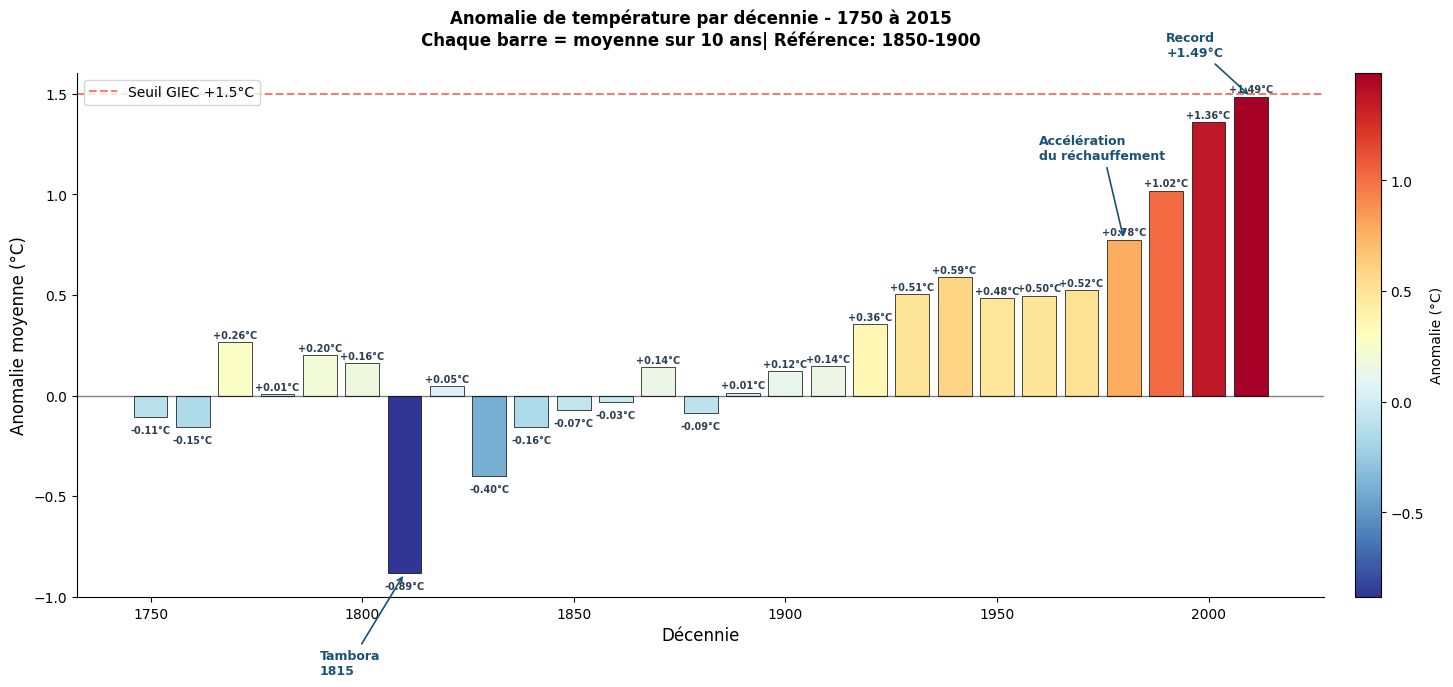


 Les décennies les plus chaudes : 
Décennie 2010-> +1.49°C
Décennie 2000-> +1.36°C
Décennie 1990-> +1.02°C
Décennie 1980-> +0.78°C
Décennie 1940-> +0.59°C


In [18]:
fig,ax = plt.subplots(figsize=(16,7))
norm = Normalize(
    vmin=df_decennie['anomalie_moy'].min(),
    vmax=df_decennie['anomalie_moy'].max()
)
couleurs = [RdYlBu_r(norm(v)) for v in df_decennie['anomalie_moy']]
bars = ax.bar(
    df_decennie['decennie'],df_decennie['anomalie_moy'],color=couleurs,width=8,
    edgecolor='black',linewidth=0.5
)
for bar, val in zip(bars,df_decennie['anomalie_moy']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() +0.02 if val >=0 else bar.get_height() - 0.08,
        f'{val:+.2f}°C',ha='center',fontsize=7,fontweight='bold',color='#2C3E50'
    )
ax.axhline(y=0,color='black',linewidth=1, alpha=0.5)
ax.axhline(y=1.5, color='#E74C3C',linewidth=1.5,linestyle='--',alpha=0.7,label='Seuil GIEC +1.5°C')
sm = cm.ScalarMappable(cmap=RdYlBu_r,norm=norm)
sm.set_array([])
cbar=plt.colorbar(sm,ax=ax,pad=0.02)
cbar.set_label('Anomalie (°C)',fontsize=10)
annotations = [(1810,'Tambora\n1815',-0.5),
               (1980,'Accélération\ndu réchauffement',0.4),
               (2010,'Record\n+1.49°C',0.2)]
for annee,texte, offset in annotations:
    val=df_decennie[df_decennie['decennie']==annee]['anomalie_moy'].values[0]
    ax.annotate(
        texte, xy=(annee,val),xytext=(annee-20,val+offset),
        fontsize=9,color='#1A5276',fontweight='bold',arrowprops=dict(
            arrowstyle='->',color='#1A5276',lw=1.2
        )
    )
ax.set_title('Anomalie de température par décennie - 1750 à 2015\n'
             'Chaque barre = moyenne sur 10 ans'
             '| Référence: 1850-1900',
             fontsize=12, fontweight='bold',pad=20)
ax.set_xlabel('Décennie',fontsize=12)
ax.set_ylabel('Anomalie moyenne (°C)', fontsize=12)
ax.legend(fontsize=10,loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/03_anomalies_decennies.png",dpi=150,bbox_inches='tight')
plt.show()
print("\n Les décennies les plus chaudes : ")
top5 = df_decennie.nlargest(5,'anomalie_moy')
for _, row in top5.iterrows():
    print(f"Décennie {row['decennie']:.0f}"
          f"-> +{row['anomalie_moy']:.2f}°C")

In [40]:
#Apprentissage du model pour prédiction.

In [49]:
X= df_annuel[['Year']].values
y= df_annuel['temp_moyenne'].values
#--- Préparation X et y --------
print(f"X (annees)      : {X.shape}")
print(f"y (températures) : {y.shape}")
print(f"X va de {X.min()} à {X.max()}")
print(f"y va de {y.min():.2f}°C à {y.max():.2f}°C")
#---Split train/test -------
split = int(len(X)*0.8)
X_train, X_test = X[:split] , X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train: {len(X_train)} années : "
      f"({X_train.min()} -> {X_train.max()} )")
print(f"Test : {len(X_test)} années "
      f"({X_test.min()} -> {X_test.max()})")
# -- Années futures pour la prédiction ------
# On créeun tableau de 2016 à 2100
annees_futures = np.arange(2016, 2101).reshape(-1,1)
print(f"Années futures : 2016 -> 2100 "
      f"({len(annees_futures)} années)")


X (annees)      : (266, 1)
y (températures) : (266,)
X va de 1750 à 2015
y va de 5.78°C à 9.83°C
Train: 212 années : (1750 -> 1961 )
Test : 54 années (1962 -> 2015)
Années futures : 2016 -> 2100 (85 années)


In [61]:
# Modèle 1: Régressions Linéaire ----------
model_lr = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])
model_lr.fit(X_train,y_train)
# Modèle 2 : Régression Polynomiale dedré 3 --------
model_poly = Pipeline([
    ('poly',PolynomialFeatures(degree=3)),
     ('scaler',StandardScaler()),
     ('model',LinearRegression())]
)
model_poly.fit(X_train, y_train)
# ---------Modèle 3 : Gradient Boosting ---------
model_gb = Pipeline([
    ('scaler',StandardScaler()),
    ('model',GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
model_gb.fit(X_train, y_train)
#------- Évalution sur le test ---------
modeles = {
    'Régression Linéaire' : model_lr,
    'Polynomiale degré 3': model_poly,
    'Gradien Boosting' : model_gb
}
print("="*55)
print(" Résultats sur la période test (2003-2015)")
print("="*55)
resultats = {}
for nom, modele in modeles.items():
    y_pred = modele.predict(X_test)
    r2 = r2_score(y_test,y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    resultats[nom] = {
        'model':modele,
        'r2':r2,
        'mae':mae,
        'preds':y_pred
    }
    print(f"\n {nom}")
    print(f" R2 : {r2:.4f}")
    print(f" MAE : {mae:.4f}°C")

 Résultats sur la période test (2003-2015)

 Régression Linéaire
 R2 : -1.2869
 MAE : 0.5016°C

 Polynomiale degré 3
 R2 : 0.4565
 MAE : 0.2436°C

 Gradien Boosting
 R2 : -0.7411
 MAE : 0.4193°C


In [70]:

corr_p, pval_p = stats.pearsonr(
    df_annuel['Year'],
    df_annuel['temp_moyenne']
)
corr_s, pval_s = stats.spearmanr(
    df_annuel['Year'],
    df_annuel['temp_moyenne']
)
print("=" * 50)
print("Pearson vs Spearman")
print("=" * 50)
print(f"Person r : {corr_p:.4f}")
print(f"Spearman r: {corr_s:.4f}")
print(f"Différence: {abs(corr_s - corr_p):.4f}")
if abs(corr_s - corr_p) < 0.05:
    print(" -> Relation Linéaire")
else:
    print(" -> Relation Non Linéaire")
print("\n" + '=' *50)
print("R2 Selon le defré polynomial")
print("=" * 50)
for degree in range(1,6):
    model = Pipeline([
        ('poly',PolynomialFeatures(degree=degree)),
        ('model',LinearRegression())
    ])
    model.fit(
        df_annuel[['Year']].values,
        df_annuel['temp_moyenne'].values
    )
    r2 = r2_score(
        df_annuel['temp_moyenne'].values,
        model.predict(df_annuel[['Year']].values)
    )
    barre = "*" * int(r2 * 30)
    label = '<- Linéaire' if degree == 1 else ''
    print(f" Degré {degree} : {r2:.4f} {barre}{label}")
    

Pearson vs Spearman
Person r : 0.6223
Spearman r: 0.6144
Différence: 0.0079
 -> Relation Linéaire

R2 Selon le defré polynomial
 Degré 1 : 0.3873 ***********<- Linéaire
 Degré 2 : 0.5309 ***************
 Degré 3 : 0.5323 ***************
 Degré 4 : 0.5324 ***************
 Degré 5 : 0.5324 ***************
